In [204]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path(".") # change to path folder with data 

import matplotlib.pyplot as plt
import seaborn as sns


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

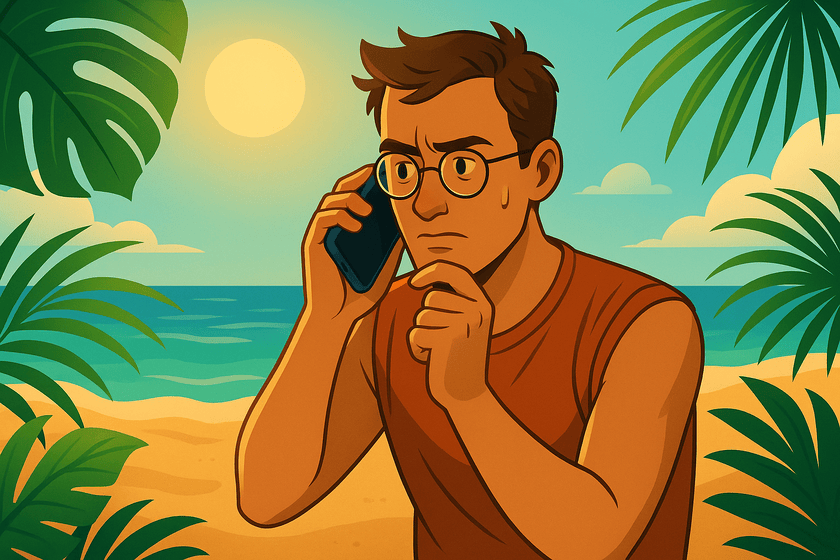

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [246]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [247]:
def get_percentage_missing(df, axis):
    missing_rows = df.isna().sum(axis=axis)
    missing_rows_perc = np.round(missing_rows/df.shape[axis]*100,1)
    return missing_rows_perc[missing_rows_perc > 0]

In [248]:
missing_col = get_percentage_missing(titanic_df,axis=0)
missing_col

Age         19.9
Fare        11.0
Cabin       77.1
Embarked     0.2
dtype: float64

**Cabin:** Dla większości paseżerów numer kabiny nie jest przypisany(77,1%). Najlepszym rozwiązaniem chyba będzie utworzenie nowej kategerii "Other",ponieważ przy całkowitym usunięciu kolumny możemy stracić cenną informację (w danych dodatkowo mam klasy, możliwe że brak informacji o numeru kabiny powiązany z numerem klasy).A losowanie na podstawie danych niebrakujących może byc błedne (Możemy wylosować dla pasażera klasy 3 kabinę, która znajduje sie w innej klasie)

In [249]:
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')

**Age:** Tutaj mamy prawie 20% brakujących danych. Na początku trzeba sprawdzić rozkład dla kolumny Age. 

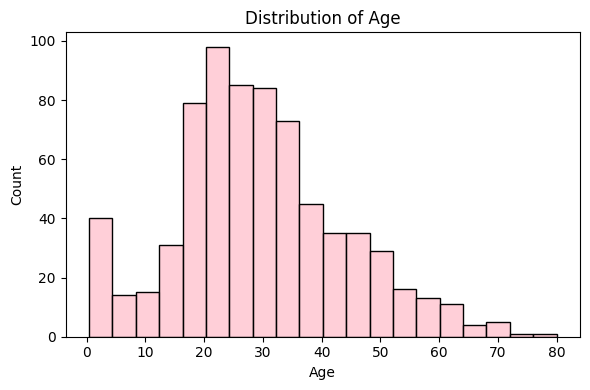

In [250]:
def histplot(df,col):
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, color='pink', bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

histplot (titanic_df,'Age')

Rozdład jest prawostronnie asymetryczny, więc zamieniam wartości brakujące mediną

In [251]:
median_age = titanic_df.Age.median()
titanic_df['Age'] = titanic_df['Age'].fillna(median_age)


**Fare:** Rozkład jest prawostronnie asymetryczny,więc zamieniam brakujące wartosci medianą

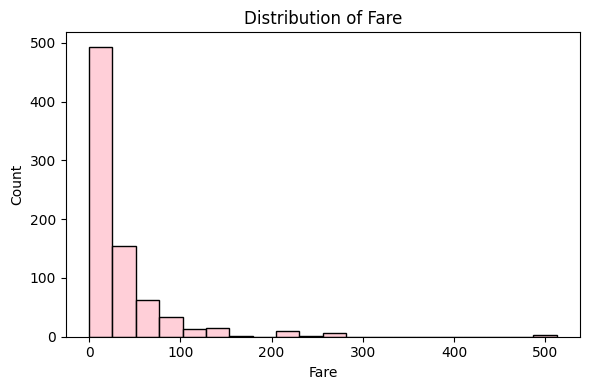

In [252]:
histplot(titanic_df,'Fare')

In [253]:
median_fare = titanic_df.Fare.median()
titanic_df['Fare'] = titanic_df['Fare'].fillna(median_fare)

**Embarked:** Procent wartości brakujących jest bardzo niski, więc możemy zamienić najczęstszą wartością.

In [254]:
titanic_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [255]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')

In [256]:

titanic_df[['Age', 'Embarked', 'Cabin', 'Fare']].isna().sum()

Age         0
Embarked    0
Cabin       0
Fare        0
dtype: int64

Następnie dodałam nowe kolumne IsAlone i AgeGroup. Dla kolumny IsAlone są dwie wartości 1 - pasażer podróżajcy sam, 0 - z rodziną. W kolumnue AgeGroup zrobilam rozdzielenie ma child (0-12),teenager (13-18),adult(19-60),senior(61-100).

In [257]:
family_size = titanic_df['Parch'] + titanic_df['SibSp'] + 1
titanic_df['IsAlone']=(family_size==1).astype(int)

bins_age = [0,12,18,60,100]
labels_age = ['Child','Teenager','Adult','Senior']
titanic_df['AgeGroup'] = pd.cut(titanic_df['Age'],bins=bins_age,labels=labels_age)

titanic_df['IsCabin'] = (titanic_df['Cabin'] != 'Unknown').astype(int)

titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsAlone,AgeGroup,IsCabin
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,0,Adult,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,Adult,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,1,Adult,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,Adult,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,1,Adult,0


Kolumne Name i Ticket nie są przydatne, ponieważ prawie każdy pasażer ma unikalne wartości w tych kolumnach i da się z tego coś wywnioskować. Dodatkowo usunęłam Cabin, ponieważ zrobiłam odrębną klasę IsCabin

In [258]:
titanic_df.drop(columns=['Ticket', 'Name', 'Cabin'],inplace=True)

**Wykresy porównania przeżywalności**

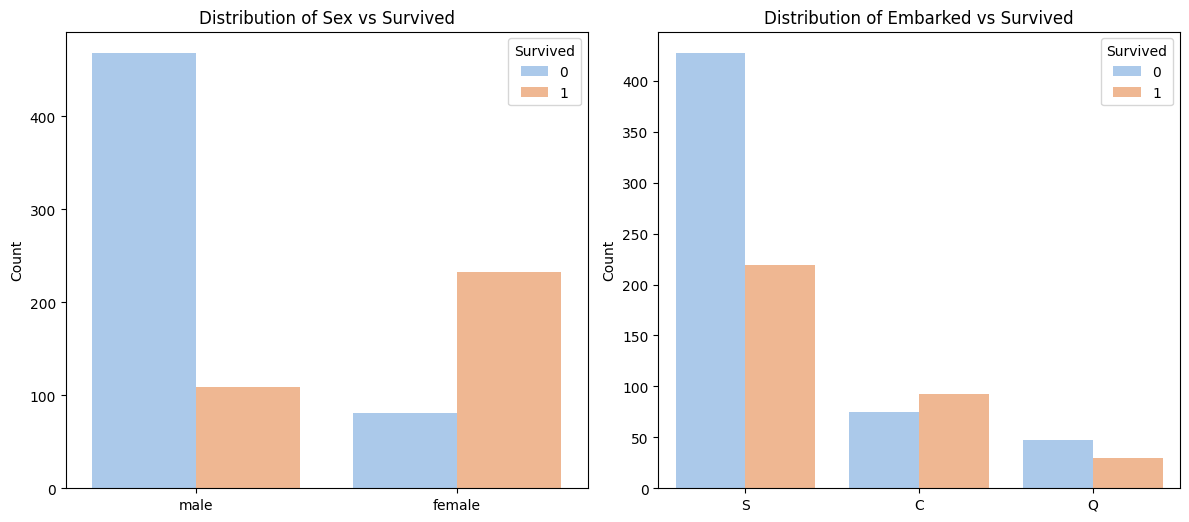

In [ ]:
def plot_categorical_distributions(df):
    categorical_columns = df.select_dtypes(include='object').columns
    plt.figure(figsize=(2 * 6, 3 * 5))

    for idx, column in enumerate(categorical_columns, 1):
        plt.subplot(3, 2, idx)
        sns.countplot(x=column, hue='Survived', data=df, palette='pastel')
        plt.title(f'Distribution of {column} vs Survived')
        plt.xlabel('')
        plt.ylabel('Count')

    plt.tight_layout()
    plt.show()


plot_categorical_distributions(titanic_df)

In [260]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,IsAlone,AgeGroup,IsCabin
PassengerId,,,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S,0,Adult,0
2,1,1,female,38.0,1,0,71.2833,C,0,Adult,1
3,1,3,female,26.0,0,0,7.9250,S,1,Adult,0
4,1,1,female,35.0,1,0,53.1000,S,0,Adult,1
5,0,3,male,35.0,0,0,8.0500,S,1,Adult,0


Dalej dla wartości kategorialnych wykonałam kodowanie kolumn. W przypadku AgeGroup zrobiłam kodowanie ordinal, ponieważ występuje między nimi porządek. Dla Sex zrobiłam kodowanie binarne (male - 0, female - 1).Kolumne Embarked nie ma naturalnego porządku, więc zrobiłam One-Hot Encoding

In [261]:
mapping = {
    'Child' : 0,
    'Teenager' : 1,
    'Adult' : 2,
    'Senior' : 3,
}

titanic_df['AgeGroup'] = titanic_df['AgeGroup'].map(mapping)

titanic_df['AgeGroup'].value_counts()

AgeGroup
2    730
1     70
0     69
3     22
Name: count, dtype: int64

In [262]:
titanic_df['Sex'] = titanic_df.Sex.map({ 'male': 0 , 'female' :1})

titanic_df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [263]:
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], prefix='Embarked', dtype=int)
titanic_df.head(1)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,IsAlone,AgeGroup,IsCabin,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.25,0,2,0,0,0,1


**Rozkład z wartościami skrajnymi**

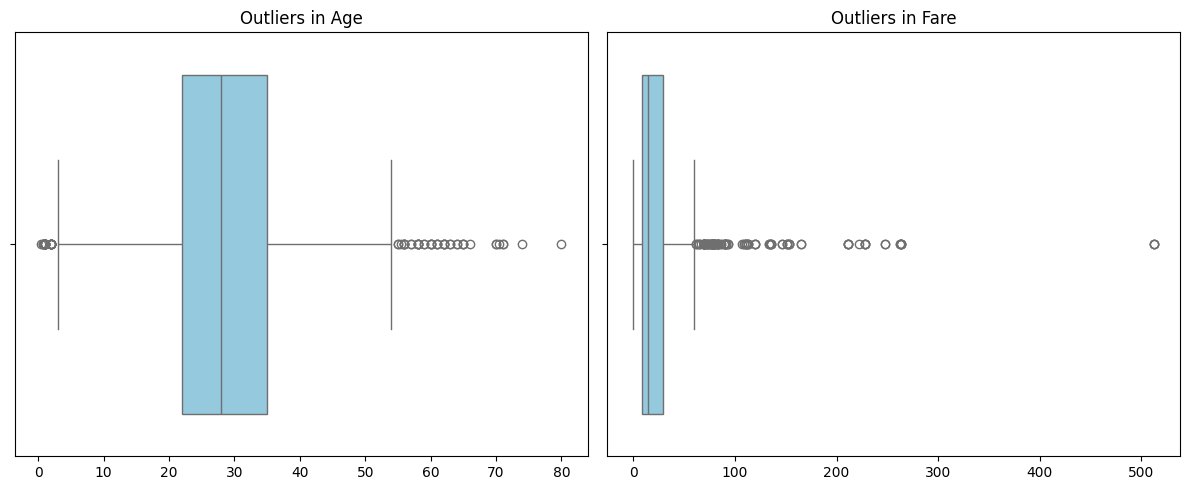

In [264]:
def plot_outliers(df):
    columns = ['Age', 'Fare']
    plt.figure(figsize=(2 * 6, 1 * 5))

    for idx, column in enumerate(columns, 1):
        plt.subplot(1, 2, idx)
        sns.boxplot(x=df[column], color='skyblue')
        plt.title(f'Outliers in {column}')
        plt.xlabel('')

    plt.tight_layout()
    plt.show()


plot_outliers(titanic_df)

In [265]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

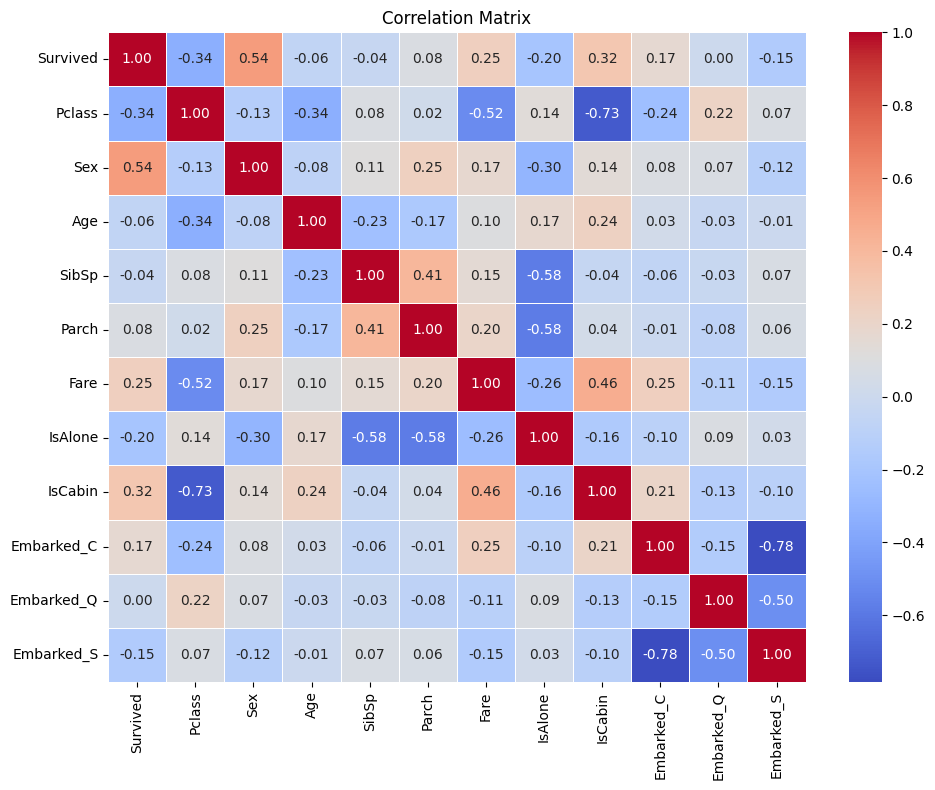

In [266]:

def plot_correlation_matrix(df):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

plot_correlation_matrix(titanic_df)

**Wniosek:**
Mimo tego,że zrobiłam większość zadania, wizualizacja danych nie została zakończona. 

Zauważyłam, że zastąpienie brakujących wartości w kolumnie Age medianą nie było najlepszym pomysłem, ponieważ ono może zaburzyć relację z przeżywalnością

P.s. przepraszam za bałagan